In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import json

from loguru import logger
from pymatgen.core import Structure

from src.datasets import MaterialsProject

In [3]:
mp = MaterialsProject()
mp.load(force_fetch=True)

2026-03-23 21:24:50.440 | INFO     | src.datasets:_fetch_from_api:1036 - Fetching 1000 stable oxides from API. Using stratified sampling.


Retrieving SummaryDoc documents:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing materials: 100%|██████████| 1000/1000 [00:00<00:00, 5212.13it/s]
2026-03-23 21:24:56.296 | INFO     | src.datasets:_get_structures:1201 - Reconstructing Pymatgen structures from JSON...
Reconstructing structures: 100%|██████████| 1000/1000 [00:00<00:00, 5849.40it/s]
2026-03-23 21:25:10.402 | INFO     | src.datasets:_add_descriptors:1220 - Computing Periodic SOAP for 1000 structures...
SOAP progress: 100%|██████████| 32/32 [00:02<00:00, 14.64it/s]


SOAP features shape: 1000 x 252


2026-03-23 21:25:14.192 | SUCCESS  | src.datasets:_add_descriptors:1239 - SOAP embeddings added.
2026-03-23 21:25:14.193 | INFO     | src.datasets:_add_descriptors:1243 - Computing Periodic ACSF for 1000 structures...
ACSF progress: 100%|██████████| 32/32 [00:02<00:00, 11.72it/s]
2026-03-23 21:25:17.319 | SUCCESS  | src.datasets:_add_descriptors:1271 - ACSF embeddings averaged and added.
2026-03-23 21:25:17.471 | SUCCESS  | src.datasets:_fetch_from_api:1088 - Dataset saved with 1000 entries.


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-19359""","""NaFeO2""",-6.72479,-1.797874,1.9919,false,"""{""@module"": ""pymatgen.core.str…","""Trigonal""","""R-3m""",4.371677,5.614292,5.614292,5.614291,31.183234,31.183221,31.183226,42.099058,4,"[38.712658, 114.179498, … 138.847002]","[0.0, 0.0, … 0.0]"
"""mp-3098""","""AlCuO2""",-6.8528,-2.417624,1.8148,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P6_3/mmc""",5.146334,2.842773,2.842773,11.297846,90.0,90.0,120.000003,79.069786,8,"[47.437852, 131.548353, … 522.766598]","[0.0, 0.0, … 0.0]"
"""mp-757594""","""Os(OF2)2""",-5.952115,-1.840872,1.9012,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P6_1""",4.882321,5.021161,5.021161,27.872457,90.0,90.0,119.99999,608.575224,42,"[73.835733, 199.875807, … 59.746609]","[0.0, 0.0, … 0.0]"
"""mp-757614""","""LiFeO2""",-7.013653,-1.944937,1.7125,false,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pmmn""",4.365993,4.084498,6.006037,2.939057,89.999993,90.000053,89.999863,72.099917,8,"[27.94558, 81.265758, … 58.323098]","[0.0, 0.0, … 0.0]"
"""mp-866101""","""AcCrO3""",-8.862593,-3.138972,2.0031,false,"""{""@module"": ""pymatgen.core.str…","""Cubic""","""Pm-3m""",8.848788,3.9442869,3.944302,3.9442715,90.0,90.0,90.0,61.362845,5,"[173.384956, 482.119308, … 0.035966]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-697084""","""HPbIO""",-4.609982,-1.215035,2.7209,false,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pnma""",6.474417,4.259886,7.945161,10.642733,90.0,90.0,90.0,360.208408,16,"[293.931589, 841.954258, … 118.34263]","[1.769042, 0.246415, … 0.0]"
"""mp-768976""","""Cs3ScO3""",-5.679866,-2.26554,3.0416,false,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""P2_1/c""",4.665646,7.345891,8.126791,11.789946,83.977032,90.0,90.0,699.957042,28,"[206.453222, 582.772063, … 446.576292]","[0.0, 0.0, … 0.0]"
"""mp-2789""","""NO2""",-6.763752,-0.685686,2.8265,false,"""{""@module"": ""pymatgen.core.str…","""Cubic""","""Im-3""",2.00156,6.675561,6.675562,6.6755616,109.471218,109.471219,109.471217,229.003202,18,"[11.557586, 31.899468, … 71.545314]","[0.0, 0.0, … 0.0]"


In [4]:
mp.df["raw_structure"][0]

'{"@module": "pymatgen.core.structure", "@class": "Structure", "charge": 0, "lattice": {"matrix": [[2.90353776, -0.00242109, 4.80517825], [1.33719614, 2.57729449, 4.80517825], [-0.003985799999999, -0.00242109, 5.61428905]], "pbc": [true, true, true], "a": 5.614292065763561, "b": 5.614292334683715, "c": 5.614290986868095, "alpha": 31.18323421961096, "beta": 31.18322056022044, "gamma": 31.18322550847327, "volume": 42.0990578309216}, "properties": {}, "sites": [{"species": [{"element": "Na", "occu": 1}], "abc": [0.0, -0.0, 0.0], "properties": {"magmom": 0.007}, "label": "Na", "xyz": [0.0, 0.0, 0.0]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.5, 0.5, 0.5], "properties": {"magmom": 4.134}, "label": "Fe", "xyz": [2.118374050000001, 1.286226155, 7.612322775000001]}, {"species": [{"element": "O", "occu": 1}], "abc": [0.76513884, 0.76513884, 0.76513884], "properties": {"magmom": 0.34700000000000003}, "label": "O", "xyz": [3.2417005266062047, 1.9682831764287203, 11.648967635538162]},

In [9]:
mp.df["acsf_embedding"][0].to_list()

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 7.954203870899219,
 0.5839212047854451,
 3.0566631062944536,
 4.548400864898373,
 0.0,
 0.0,
 0.0,
 0.0,
 3.9589533552098968,
 0.180284244482644,
 1.3375501596607624,
 2.4132647819617548,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 3.9847196449440734,
 0.3810752268454037,
 1.565348515150855,
 2.2506396616573685,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0

In [6]:
duplicate_embeddings = mp.df.join(
    mp.df.group_by("acsf_embedding")
        .len()
        .filter(pl.col("len") > 1),
    on="acsf_embedding"
)

duplicate_embeddings

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding,len
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],u32


# Plots for investegating

In [7]:
def plot_crystal_system_diversity(df: pl.DataFrame):
    """
    Generates a bar plot showing the distribution of crystal systems.
    """
    logger.info("Generating Crystal System distribution plot...")
    
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Fix: Added x as hue and set legend=False to satisfy new Seaborn syntax
    ax = sns.barplot(
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
        hue=crystal_counts["crystal_system"].to_list(),
        palette="magma",
        edgecolor=".2",
        legend=False 
    )

    plt.title("Materials Project: Diversity of Crystal Systems", fontsize=15, fontweight='bold')
    plt.xlabel("Crystal System", fontsize=12)
    plt.ylabel("Count (Number of Materials)", fontsize=12)
    plt.xticks(rotation=45)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/crystal_system_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_volume_distribution(df: pl.DataFrame):
    """
    Generates a KDE plot for Lattice Volume distribution across crystal systems.
    """
    logger.info("Generating Volume Distribution plot...")
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # Fix: Capture the axes object 'ax'
    ax = sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.4,
        palette="viridis"
    )

    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=15, fontweight='bold')
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    
    # Fix: Use sns.move_legend instead of plt.legend()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Crystal System")
    
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/volume_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    logger.success("Visualization complete.")

2026-03-23 21:25:17.794 | INFO     | __main__:plot_crystal_system_diversity:5 - Generating Crystal System distribution plot...


FileNotFoundError: [Errno 2] No such file or directory: 'report/materials_project/figures/initial_analysis/crystal_system_diversity.png'

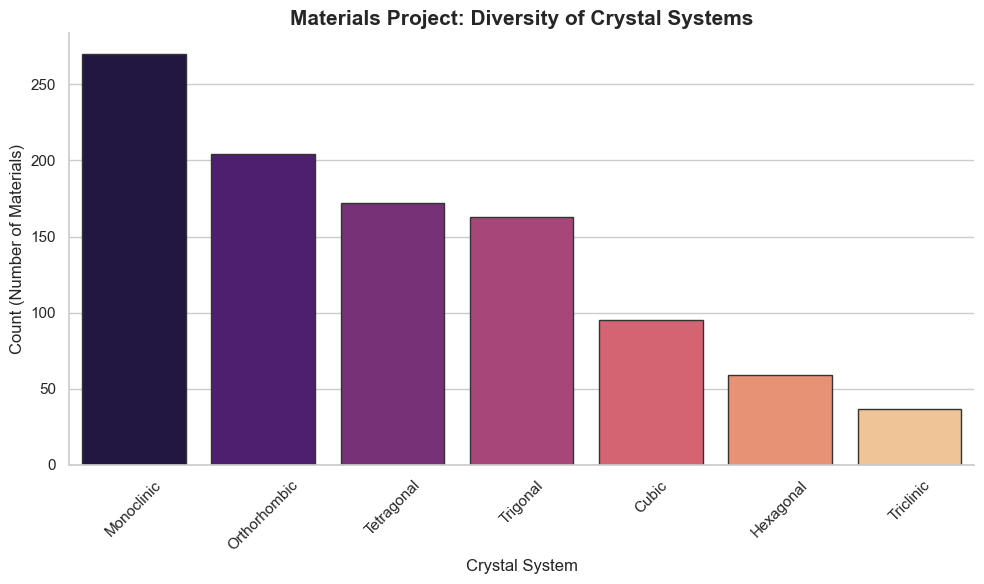

In [8]:
plot_crystal_system_diversity(mp.df)
plot_volume_distribution(mp.df)

# Show raw structure

In [ ]:
mp.df['formula_pretty'][0]

'FeO'

In [ ]:
struct_json = mp.df["raw_structure"][0]
struct = Structure.from_dict(json.loads(struct_json))
print(struct)
struct

Full Formula (Fe4 O4)
Reduced Formula: FeO
abc   :   3.102294   5.375696   5.443817
angles: 110.556657  91.096992  89.946600
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Fe    0.5       0         0.5         -3.73
  1  Fe    0         0.5       0.5         -3.727
  2  Fe    0         0         0            3.73
  3  Fe    0.500001  0.5       0            3.727
  4  O     0.968291  0.251676  0.742066    -0.006
  5  O     0.468313  0.251673  0.242068     0.006
  6  O     0.031709  0.748324  0.257934    -0.006
  7  O     0.531686  0.748327  0.757932     0.006


Structure Summary
Lattice
    abc : 3.1022937640270305 5.375695840657374 5.443817206669784
 angles : 110.55665728789754 91.09699169817493 89.9466003593816
 volume : 84.98847683834407
      A : np.float64(2.176648) np.float64(-2.210439) np.float64(-0.019736)
      B : np.float64(2.157691) np.float64(2.157191999999999) np.float64(-4.425946)
      C : np.float64(2.163513) np.float64(2.236831) np.float64(4.466648)
    pbc : True True True
PeriodicSite: Fe (2.17, 0.0132, 2.223) [0.5, 0.0, 0.5]
PeriodicSite: Fe (2.161, 2.197, 0.02035) [0.0, 0.5, 0.5]
PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Fe (2.167, -0.02663, -2.223) [0.5, 0.5, 0.0]
PeriodicSite: O (4.256, 0.06244, 2.182) [0.9683, 0.2517, 0.7421]
PeriodicSite: O (2.086, 0.04919, -0.0419) [0.4683, 0.2517, 0.2421]
PeriodicSite: O (2.242, 2.121, -2.161) [0.03171, 0.7483, 0.2579]
PeriodicSite: O (4.412, 2.134, 0.06287) [0.5317, 0.7483, 0.7579]

In [ ]:
from chemiscope import show
from pymatgen.io.ase import AseAtomsAdaptor

adaptor = AseAtomsAdaptor()
atoms = adaptor.get_atoms(struct)
#show(atoms, mode="structure")
atoms_super = atoms.repeat([2,2,2])
show([atoms_super], mode="structure")

<StructureWidget(meta={'name': ' '}, structures=[{'size': 64, 'data': 'structure-0'}], properties={'index': {'…